In [1]:
# %% 
# ------------------------------------------------------------
# Configuración general: imports, tipo de problema y utilidades
# ------------------------------------------------------------

import numpy as np
from scipy.optimize import minimize, line_search
import time


# Fijamos semilla para reproducibilidad
np.random.seed(42)

# Pequeña utilidad para registrar el historial de la optimización
class OptimizationHistory:
    def __init__(self):
        self.x_hist = []
        self.f_hist = []
        self.grad_norm_hist = []
        self.time_hist = []

    def append(self, x, fval, grad, t):
        self.x_hist.append(x.copy())
        self.f_hist.append(float(fval))
        self.grad_norm_hist.append(float(np.linalg.norm(grad)))
        self.time_hist.append(t)


# %%
# ------------------------------------------------------------
# Definición de funciones objetivo
# 1) Regresión logística (para GD, SGD, Adam, AdamW, BFGS, L-BFGS)
# 2) Rosenbrock 2D (problema clásico no convexo)
# ------------------------------------------------------------

# Generamos un dataset sintético para regresión logística binaria
def make_logistic_data(n_samples=500, n_features=10, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n_samples, n_features))
    w_true = rng.normal(size=n_features)
    logits = X @ w_true
    probs = 1 / (1 + np.exp(-logits))
    y = rng.binomial(1, probs)
    return X, y, w_true


X_log, y_log, w_true_log = make_logistic_data(n_samples=500, n_features=10, seed=123)


# Función de pérdida logística con regularización L2
def logistic_loss(w, X, y, l2=1e-3):
    # w: vector de parámetros (n_features,)
    z = X @ w
    # Evitar overflow numérico
    z_clip = np.clip(z, -50, 50)
    log_likelihood = -np.mean(y * z_clip - np.log1p(np.exp(z_clip)))
    reg = 0.5 * l2 * np.sum(w ** 2)
    return log_likelihood + reg


def logistic_grad(w, X, y, l2=1e-3):
    z = X @ w
    z_clip = np.clip(z, -50, 50)
    p = 1 / (1 + np.exp(-z_clip))
    grad = X.T @ (p - y) / X.shape[0]
    grad += l2 * w
    return grad


# Wrapper para pasar a los optimizadores genéricos (f, grad)
def logistic_f(w):
    return logistic_loss(w, X_log, y_log, l2=1e-3)


def logistic_g(w):
    return logistic_grad(w, X_log, y_log, l2=1e-3)


# Función de Rosenbrock 2D: f(x, y) = (1 - x)^2 + 100 (y - x^2)^2
def rosenbrock_2d(x):
    x1, x2 = x[0], x[1]
    return (1 - x1) ** 2 + 100 * (x2 - x1 ** 2) ** 2


def rosenbrock_2d_grad(x):
    x1, x2 = x[0], x[1]
    df_dx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1 ** 2)
    df_dx2 = 200 * (x2 - x1 ** 2)
    return np.array([df_dx1, df_dx2], dtype=float)


# %%
# ------------------------------------------------------------
# Optimizadores basados en gradiente:
# - Gradient Descent (GD)
# - Stochastic Gradient Descent (SGD) sobre regresión logística
# - Adam
# - AdamW
# ------------------------------------------------------------

def gradient_descent(f, grad, x0, lr=1e-2, max_iter=1000, tol=1e-6):
    x = x0.astype(float).copy()
    history = OptimizationHistory()
    t0 = time.perf_counter()
    for k in range(max_iter):
        g = grad(x)
        g_norm = np.linalg.norm(g)
        fval = f(x)
        t = time.perf_counter() - t0
        history.append(x, fval, g, t)
        if g_norm < tol:
            break
        x = x - lr * g
    return x, history


def sgd_logistic(
    w0,
    X,
    y,
    lr=1e-2,
    batch_size=32,
    max_epochs=50,
    l2=1e-3,
    tol=1e-6,
):
    w = w0.astype(float).copy()
    n_samples = X.shape[0]
    history = OptimizationHistory()
    t0 = time.perf_counter()

    for epoch in range(max_epochs):
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Gradiente en el minibatch
            z = X_batch @ w
            z_clip = np.clip(z, -50, 50)
            p = 1 / (1 + np.exp(-z_clip))
            grad_batch = X_batch.T @ (p - y_batch) / X_batch.shape[0]
            grad_batch += l2 * w

            w -= lr * grad_batch

            g_full = logistic_grad(w, X, y, l2=l2)
            fval = logistic_loss(w, X, y, l2=l2)
            t = time.perf_counter() - t0
            history.append(w, fval, g_full, t)

            if np.linalg.norm(g_full) < tol:
                return w, history

    return w, history


def adam(
    f,
    grad,
    x0,
    lr=1e-3,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    max_iter=1000,
    tol=1e-6,
):
    x = x0.astype(float).copy()
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    history = OptimizationHistory()
    t0 = time.perf_counter()

    for k in range(1, max_iter + 1):
        g = grad(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g ** 2)
        m_hat = m / (1 - beta1 ** k)
        v_hat = v / (1 - beta2 ** k)
        x = x - lr * m_hat / (np.sqrt(v_hat) + eps)

        fval = f(x)
        t = time.perf_counter() - t0
        history.append(x, fval, g, t)

        if np.linalg.norm(g) < tol:
            break

    return x, history


def adamw(
    f,
    grad,
    x0,
    lr=1e-3,
    beta1=0.9,
    beta2=0.999,
    weight_decay=1e-2,
    eps=1e-8,
    max_iter=1000,
    tol=1e-6,
):
    x = x0.astype(float).copy()
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    history = OptimizationHistory()
    t0 = time.perf_counter()

    for k in range(1, max_iter + 1):
        g = grad(x)

        # Decaimiento de peso explícito (AdamW)
        x = x * (1 - lr * weight_decay)

        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g ** 2)
        m_hat = m / (1 - beta1 ** k)
        v_hat = v / (1 - beta2 ** k)
        x = x - lr * m_hat / (np.sqrt(v_hat) + eps)

        fval = f(x)
        t = time.perf_counter() - t0
        history.append(x, fval, g, t)

        if np.linalg.norm(g) < tol:
            break

    return x, history






In [2]:

# %%
# ------------------------------------------------------------
# Búsqueda lineal Wolfe-Armijo y BFGS "formal"
# Usamos scipy.optimize.line_search para imponer condiciones
# de Wolfe fuerte (incluye condición de Armijo).
# ------------------------------------------------------------

def bfgs_wolfe(f, grad, x0, max_iter=200, tol=1e-6):
    xk = x0.astype(float).copy()
    n = xk.size
    Hk = np.eye(n)  # Aproximación inicial de la inversa de la Hessiana
    gk = grad(xk)

    history = OptimizationHistory()
    t0 = time.perf_counter()

    for k in range(max_iter):
        pk = -Hk @ gk  # Dirección de búsqueda (descenso)

        # Búsqueda lineal fuerte de Wolfe (incluye Armijo)
        alpha, _, _, new_fval, old_fval, _ = line_search(
            f, grad, xk, pk, gfk=gk
        )

        # Si line_search falla, usamos un paso pequeño por defecto
        if alpha is None:
            alpha = 1e-3

        x_next = xk + alpha * pk
        g_next = grad(x_next)
        sk = x_next - xk
        yk = g_next - gk

        # Registramos historial con el nuevo punto
        t = time.perf_counter() - t0
        history.append(x_next, f(x_next), g_next, t)

        # Criterio de parada
        if np.linalg.norm(g_next) < tol:
            xk = x_next
            gk = g_next
            break

        # Actualización BFGS de la inversa de la Hessiana
        rho_k = yk @ sk
        if rho_k <= 1e-12:
            # Evita divisiones por cero o actualizaciones degeneradas
            xk = x_next
            gk = g_next
            continue

        rho_k = 1.0 / rho_k
        I = np.eye(n)
        Vk = I - rho_k * np.outer(sk, yk)
        Hk = Vk @ Hk @ Vk.T + rho_k * np.outer(sk, sk)

        xk = x_next
        gk = g_next

    return xk, history

In [3]:
# %%
# ------------------------------------------------------------
# L-BFGS usando scipy.optimize.minimize como referencia
# (L-BFGS-B con límites infinitos equivale a L-BFGS sin caja).
# ------------------------------------------------------------

def lbfgs_scipy(f, grad, x0, max_iter=200, tol=1e-6):
    history = OptimizationHistory()
    t0 = time.perf_counter()

    def callback(xk):
        g = grad(xk)
        fval = f(xk)
        t = time.perf_counter() - t0
        history.append(xk, fval, g, t)

    res = minimize(
        fun=f,
        x0=x0.astype(float),
        jac=grad,
        method="L-BFGS-B",
        options={"maxiter": max_iter, "ftol": tol},
        callback=callback,
    )

    x_opt = res.x
    # Aseguramos registrar el último estado si la callback no lo hizo
    if len(history.x_hist) == 0 or not np.allclose(history.x_hist[-1], x_opt):
        g = grad(x_opt)
        fval = f(x_opt)
        t = time.perf_counter() - t0
        history.append(x_opt, fval, g, t)

    return x_opt, history


In [4]:
# %%
# ------------------------------------------------------------
# Funciones auxiliares para ejecutar y resumir experimentos
# ------------------------------------------------------------

def summarize_history(name, history, f_true_best=None):
    f_final = history.f_hist[-1]
    grad_norm_final = history.grad_norm_hist[-1]
    n_iter = len(history.f_hist)
    t_final = history.time_hist[-1]
    if f_true_best is not None:
        gap = f_final - f_true_best
    else:
        gap = None

    print(f"--- {name} ---")
    print(f"Iteraciones: {n_iter}")
    print(f"f_final = {f_final:.6e}")
    print(f"||grad||_final = {grad_norm_final:.3e}")
    print(f"Tiempo (s) ~ {t_final:.4f}")
    if gap is not None:
        print(f"Gap vs f* (si se conoce): {gap:.3e}")
    print()


# %%
# ------------------------------------------------------------
# Experimento 1: Regresión logística
# Comparamos: GD, SGD, Adam, AdamW, BFGS (Wolfe-Armijo), L-BFGS
# ------------------------------------------------------------

# Punto inicial común
w0 = np.zeros(X_log.shape[1])

# Referencia "óptima" aproximada con L-BFGS-B (más iteraciones)
w_ref, hist_ref = lbfgs_scipy(logistic_f, logistic_g, w0, max_iter=500, tol=1e-9)
f_star = logistic_f(w_ref)
print("Valor de referencia aproximado f* (regresión logística):", f_star)
print()


# Gradient Descent clásico
w_gd, hist_gd = gradient_descent(
    logistic_f,
    logistic_g,
    w0,
    lr=1e-1,
    max_iter=2000,
    tol=1e-6,
)

# SGD sobre regresión logística
w_sgd, hist_sgd = sgd_logistic(
    w0,
    X_log,
    y_log,
    lr=5e-2,
    batch_size=32,
    max_epochs=50,
    l2=1e-3,
    tol=1e-6,
)

# Adam
w_adam, hist_adam = adam(
    logistic_f,
    logistic_g,
    w0,
    lr=1e-2,
    max_iter=2000,
    tol=1e-6,
)

# AdamW
w_adamw, hist_adamw = adamw(
    logistic_f,
    logistic_g,
    w0,
    lr=1e-2,
    weight_decay=1e-2,
    max_iter=2000,
    tol=1e-6,
)

# BFGS con búsqueda lineal de Wolfe-Armijo
w_bfgs, hist_bfgs = bfgs_wolfe(
    logistic_f,
    logistic_g,
    w0,
    max_iter=200,
    tol=1e-6,
)

# L-BFGS (ya se usó para w_ref, pero repetimos con tolerancia estándar)
w_lbfgs, hist_lbfgs = lbfgs_scipy(
    logistic_f,
    logistic_g,
    w0,
    max_iter=200,
    tol=1e-6,
)

print("=== Resumen Regresión Logística ===")
summarize_history("GD", hist_gd, f_true_best=f_star)
summarize_history("SGD", hist_sgd, f_true_best=f_star)
summarize_history("Adam", hist_adam, f_true_best=f_star)
summarize_history("AdamW", hist_adamw, f_true_best=f_star)
summarize_history("BFGS (Wolfe-Armijo)", hist_bfgs, f_true_best=f_star)
summarize_history("L-BFGS-B (scipy)", hist_lbfgs, f_true_best=f_star)



Valor de referencia aproximado f* (regresión logística): 0.40018141864890705

=== Resumen Regresión Logística ===
--- GD ---
Iteraciones: 2000
f_final = 4.001814e-01
||grad||_final = 1.290e-05
Tiempo (s) ~ 0.2905
Gap vs f* (si se conoce): 2.001e-09

--- SGD ---
Iteraciones: 800
f_final = 4.013429e-01
||grad||_final = 1.039e-02
Tiempo (s) ~ 0.1561
Gap vs f* (si se conoce): 1.162e-03

--- Adam ---
Iteraciones: 1216
f_final = 4.001814e-01
||grad||_final = 9.939e-07
Tiempo (s) ~ 0.2646
Gap vs f* (si se conoce): -4.017e-11

--- AdamW ---
Iteraciones: 2000
f_final = 4.001840e-01
||grad||_final = 4.760e-04
Tiempo (s) ~ 0.3482
Gap vs f* (si se conoce): 2.610e-06

--- BFGS (Wolfe-Armijo) ---
Iteraciones: 24
f_final = 4.001814e-01
||grad||_final = 5.433e-07
Tiempo (s) ~ 0.0125
Gap vs f* (si se conoce): -5.004e-11

--- L-BFGS-B (scipy) ---
Iteraciones: 7
f_final = 4.001814e-01
||grad||_final = 2.178e-05
Tiempo (s) ~ 0.0037
Gap vs f* (si se conoce): 2.548e-09



In [5]:
# %%
# ------------------------------------------------------------
# Experimento 2: Rosenbrock 2D
# Punto inicial lejos del mínimo global (1, 1)
# ------------------------------------------------------------

x0_rosen = np.array([-1.2, 1.0])

# Referencia "óptima" aproximada con L-BFGS-B
x_ref_rosen, hist_ref_rosen = lbfgs_scipy(
    rosenbrock_2d,
    rosenbrock_2d_grad,
    x0_rosen,
    max_iter=1000,
    tol=1e-12,
)
f_star_rosen = rosenbrock_2d(x_ref_rosen)
print("Valor de referencia aproximado f* (Rosenbrock 2D):", f_star_rosen)
print("x* aproximado:", x_ref_rosen)
print()


# GD sobre Rosenbrock (suele requerir pasos pequeños)
x_gd_rosen, hist_gd_rosen = gradient_descent(
    rosenbrock_2d,
    rosenbrock_2d_grad,
    x0_rosen,
    lr=1e-3,
    max_iter=20000,
    tol=1e-6,
)

# Adam sobre Rosenbrock
x_adam_rosen, hist_adam_rosen = adam(
    rosenbrock_2d,
    rosenbrock_2d_grad,
    x0_rosen,
    lr=1e-3,
    max_iter=10000,
    tol=1e-6,
)

# AdamW sobre Rosenbrock
x_adamw_rosen, hist_adamw_rosen = adamw(
    rosenbrock_2d,
    rosenbrock_2d_grad,
    x0_rosen,
    lr=1e-3,
    weight_decay=0.0,
    max_iter=10000,
    tol=1e-6,
)

# BFGS con Wolfe-Armijo sobre Rosenbrock
x_bfgs_rosen, hist_bfgs_rosen = bfgs_wolfe(
    rosenbrock_2d,
    rosenbrock_2d_grad,
    x0_rosen,
    max_iter=1000,
    tol=1e-6,
)

# L-BFGS-B sobre Rosenbrock (ya usado como referencia, pero repetimos con tolerancia estándar)
x_lbfgs_rosen, hist_lbfgs_rosen = lbfgs_scipy(
    rosenbrock_2d,
    rosenbrock_2d_grad,
    x0_rosen,
    max_iter=1000,
    tol=1e-6,
)

print("=== Resumen Rosenbrock 2D ===")
summarize_history("GD", hist_gd_rosen, f_true_best=f_star_rosen)
summarize_history("Adam", hist_adam_rosen, f_true_best=f_star_rosen)
summarize_history("AdamW", hist_adamw_rosen, f_true_best=f_star_rosen)
summarize_history("BFGS (Wolfe-Armijo)", hist_bfgs_rosen, f_true_best=f_star_rosen)
summarize_history("L-BFGS-B (scipy)", hist_lbfgs_rosen, f_true_best=f_star_rosen)


# %%
# ------------------------------------------------------------
# Nota: puedes añadir celdas extra para graficar las trayectorias
# en Rosenbrock 2D usando history.x_hist de cada método.
# ------------------------------------------------------------


Valor de referencia aproximado f* (Rosenbrock 2D): 1.705492796148861e-17
x* aproximado: [1.         1.00000001]

=== Resumen Rosenbrock 2D ===
--- GD ---
Iteraciones: 20000
f_final = 1.940041e-08
||grad||_final = 1.245e-04
Tiempo (s) ~ 0.5018
Gap vs f* (si se conoce): 1.940e-08

--- Adam ---
Iteraciones: 10000
f_final = 3.678027e-04
||grad||_final = 1.931e-02
Tiempo (s) ~ 0.4514
Gap vs f* (si se conoce): 3.678e-04

--- AdamW ---
Iteraciones: 10000
f_final = 3.678027e-04
||grad||_final = 1.931e-02
Tiempo (s) ~ 0.4670
Gap vs f* (si se conoce): 3.678e-04

--- BFGS (Wolfe-Armijo) ---
Iteraciones: 34
f_final = 4.715295e-17
||grad||_final = 1.051e-07
Tiempo (s) ~ 0.0049
Gap vs f* (si se conoce): 3.010e-17

--- L-BFGS-B (scipy) ---
Iteraciones: 35
f_final = 5.298561e-10
||grad||_final = 1.019e-03
Tiempo (s) ~ 0.0110
Gap vs f* (si se conoce): 5.299e-10



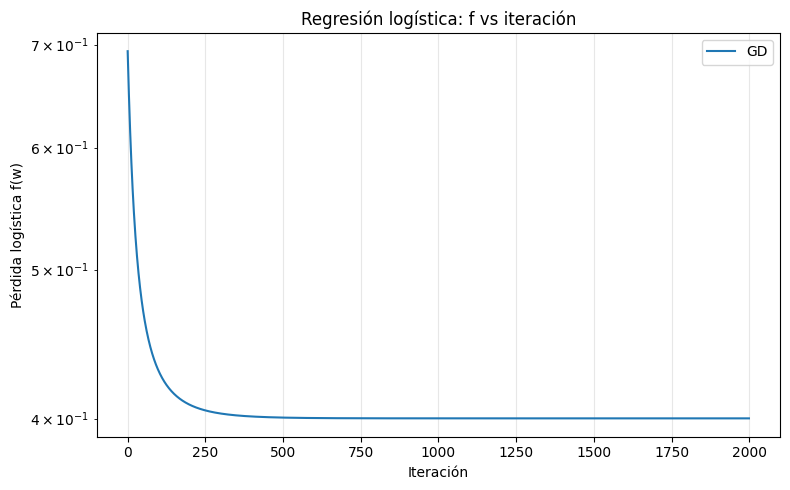

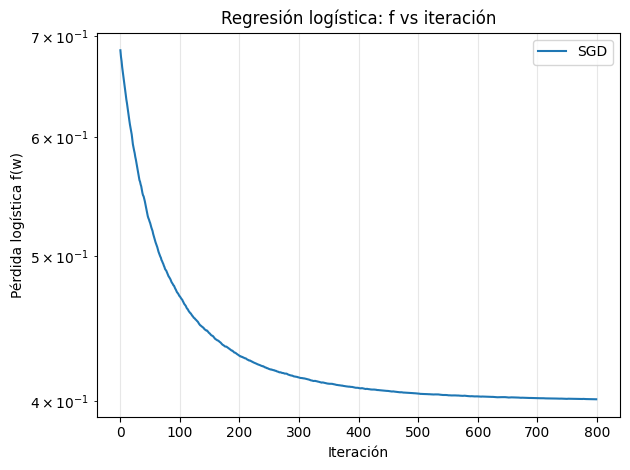

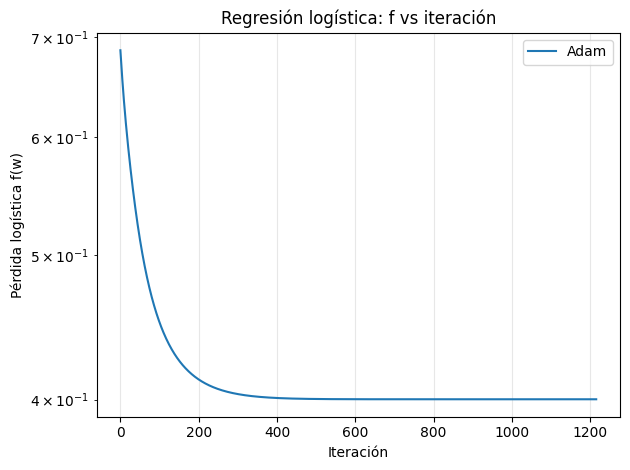

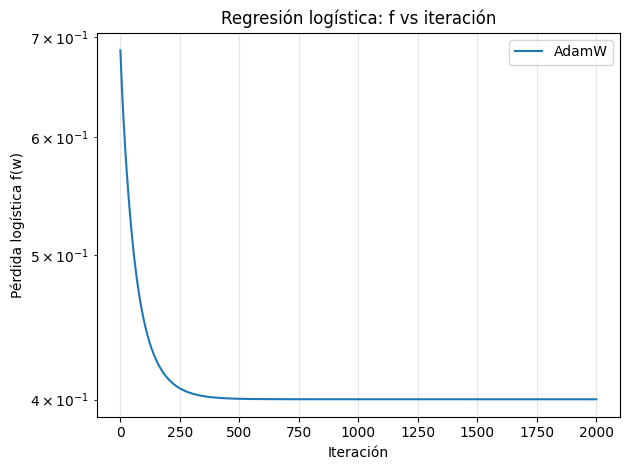

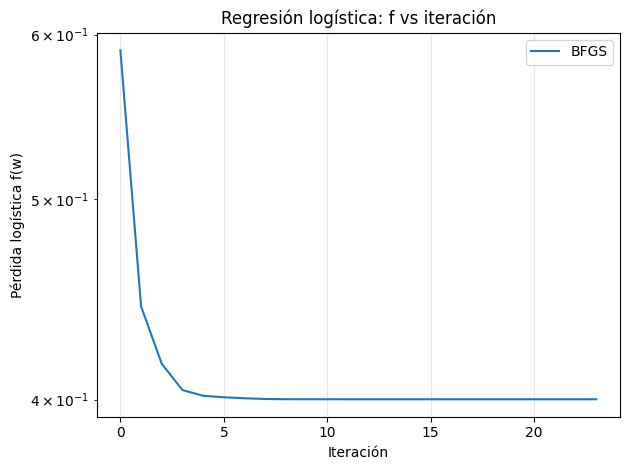

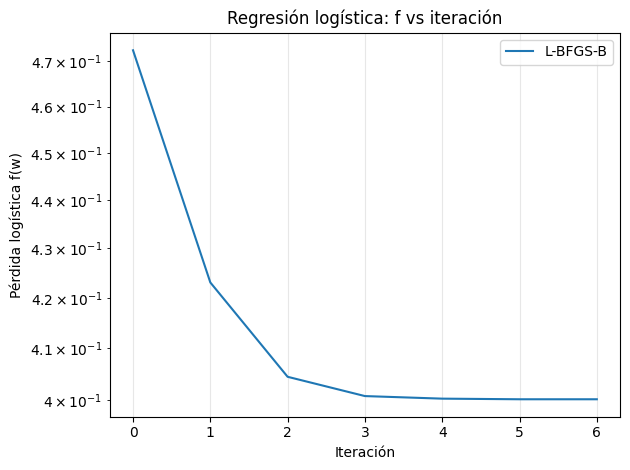

In [7]:

import matplotlib.pyplot as plt

# Lista de métodos y sus historiales

log_methods = {
"GD": hist_gd,
"SGD": hist_sgd,
"Adam": hist_adam,
"AdamW": hist_adamw,
"BFGS": hist_bfgs,
"L-BFGS-B": hist_lbfgs,
}

# f vs iteraciones

plt.figure(figsize=(8, 5))
for name, hist in log_methods.items():
    plt.plot(hist.f_hist, label=name)
    plt.yscale("log")
    plt.xlabel("Iteración")
    plt.ylabel("Pérdida logística f(w)")
    plt.title("Regresión logística: f vs iteración")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



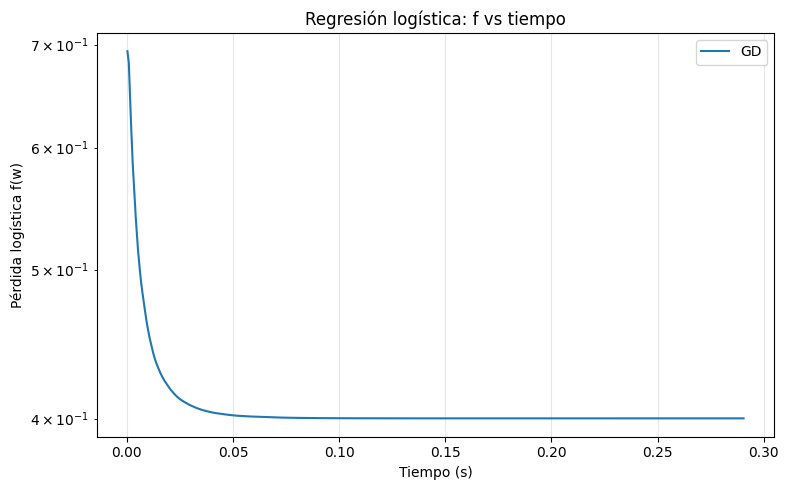

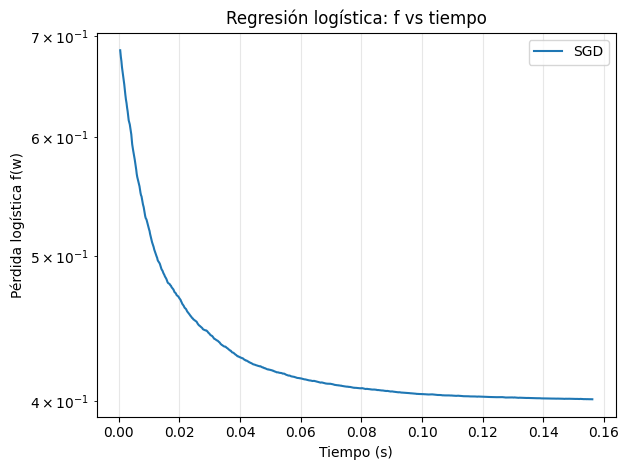

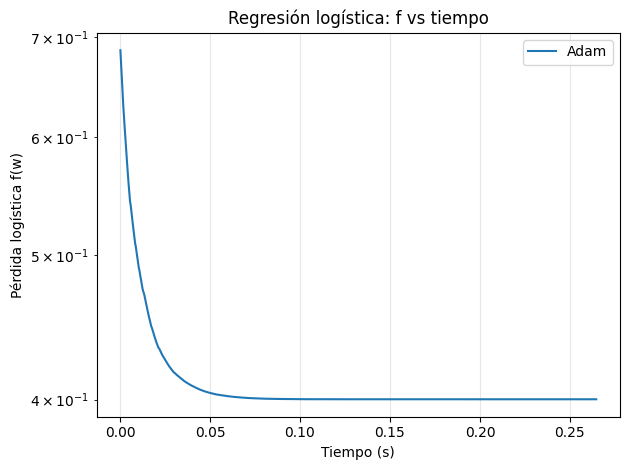

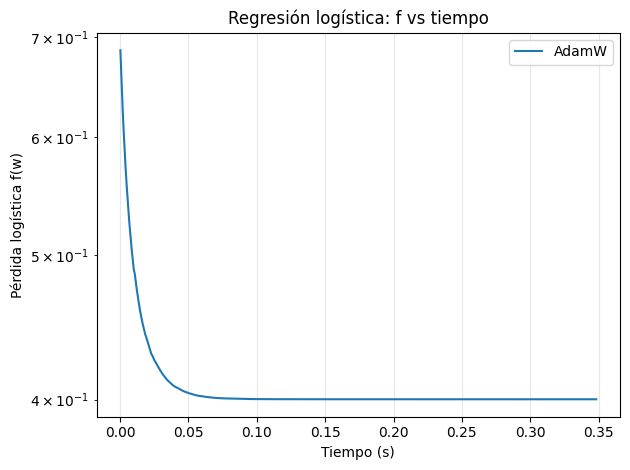

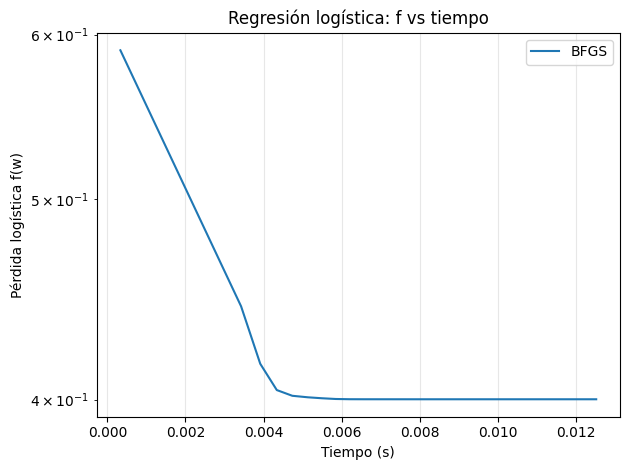

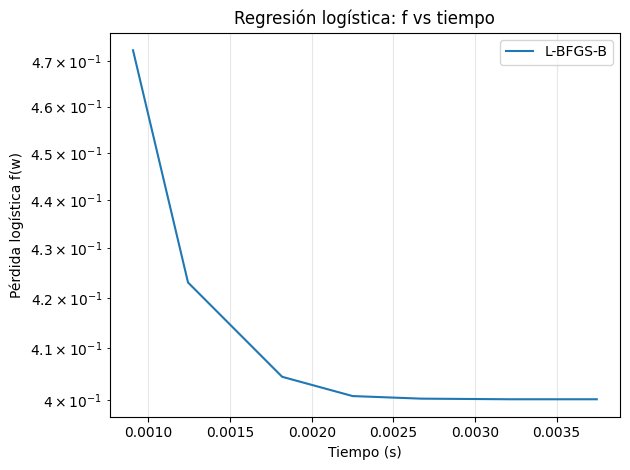

In [8]:
# f vs tiempo

plt.figure(figsize=(8, 5))
for name, hist in log_methods.items():
    plt.plot(hist.time_hist, hist.f_hist, label=name)
    plt.yscale("log")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Pérdida logística f(w)")
    plt.title("Regresión logística: f vs tiempo")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

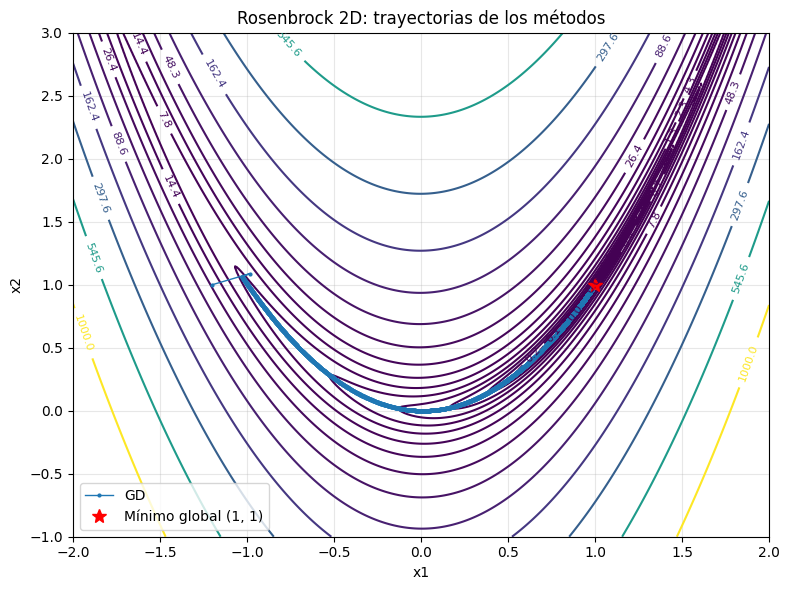

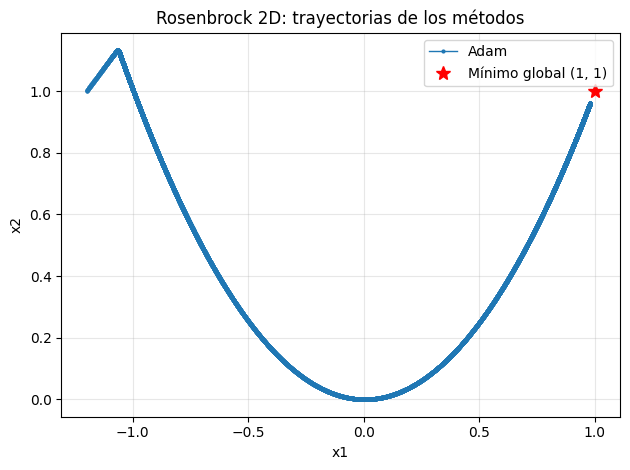

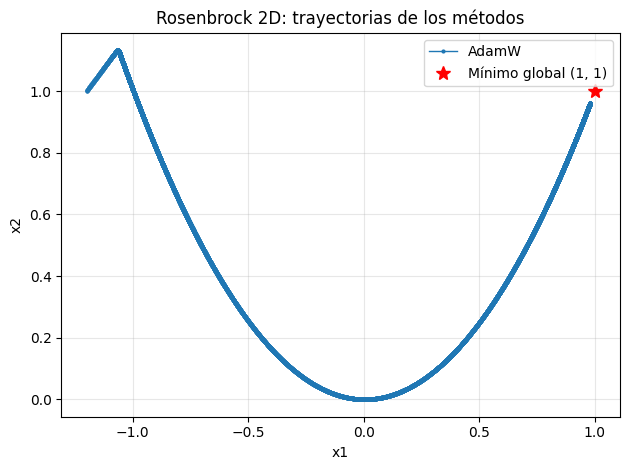

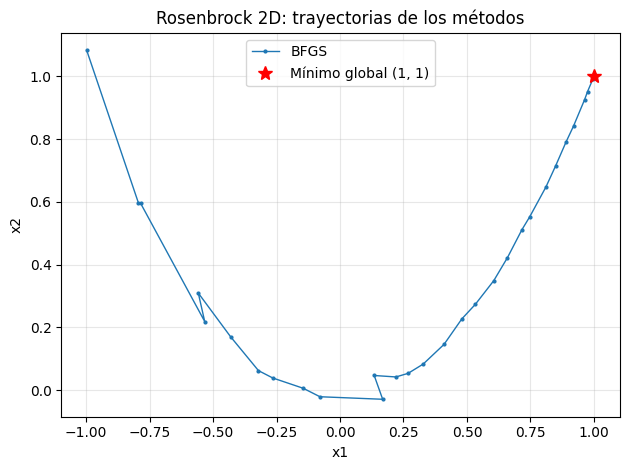

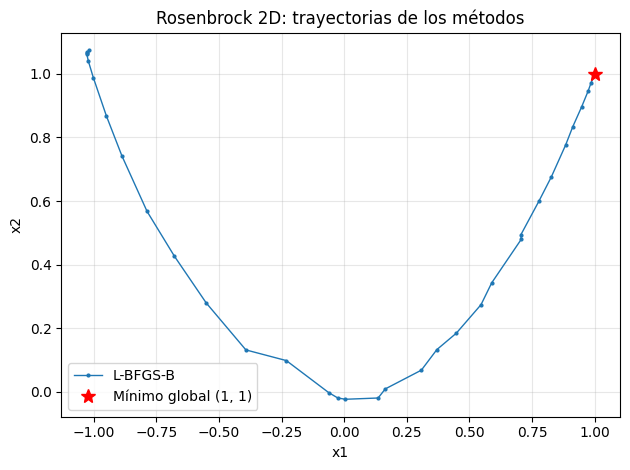

In [9]:
# Gráficos para el problema de Rosenbrock 2D:
# - Trayectorias de los métodos sobre el contorno de f(x, y)
# - f vs iteración para comparar rapidez de convergencia
# ------------------------------------------------------------

# Construimos la malla para el contorno

x1_vals = np.linspace(-2.0, 2.0, 400)
x2_vals = np.linspace(-1.0, 3.0, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = (1 - X1) ** 2 + 100 * (X2 - X1 ** 2) ** 2

# Trayectorias de cada método

rosen_methods = {
"GD": hist_gd_rosen,
"Adam": hist_adam_rosen,
"AdamW": hist_adamw_rosen,
"BFGS": hist_bfgs_rosen,
"L-BFGS-B": hist_lbfgs_rosen,
}

plt.figure(figsize=(8, 6))
CS = plt.contour(X1, X2, Z, levels=np.logspace(-2, 3, 20))
plt.clabel(CS, inline=True, fontsize=8)

for name, hist in rosen_methods.items():
    xs = np.array(hist.x_hist)
    if xs.size == 0:
        continue
    plt.plot(xs[:, 0], xs[:, 1], marker="o", markersize=2, linewidth=1, label=name)

    plt.plot(1.0, 1.0, "r*", markersize=10, label="Mínimo global (1, 1)")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Rosenbrock 2D: trayectorias de los métodos")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

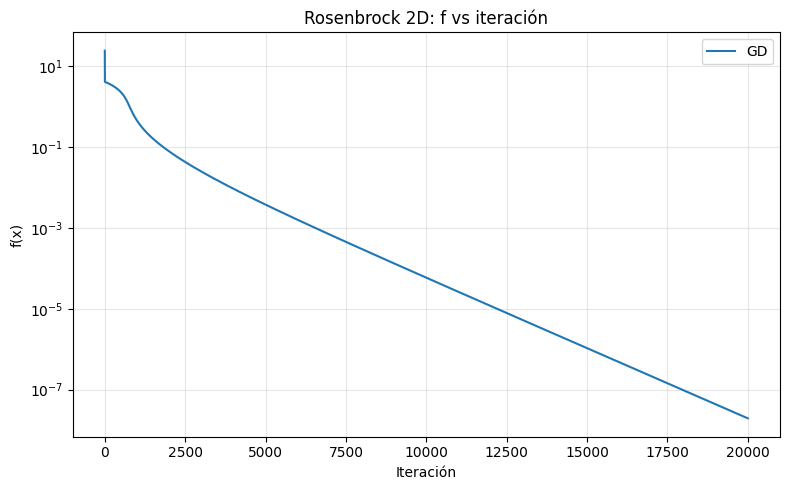

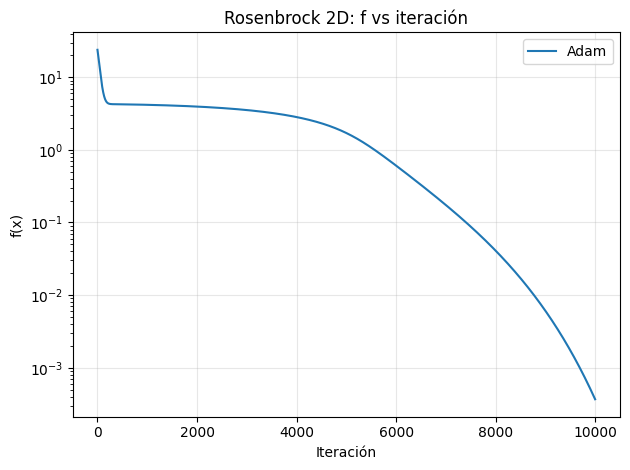

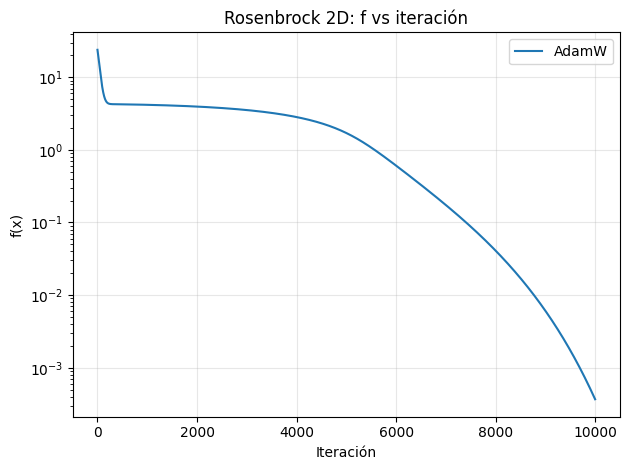

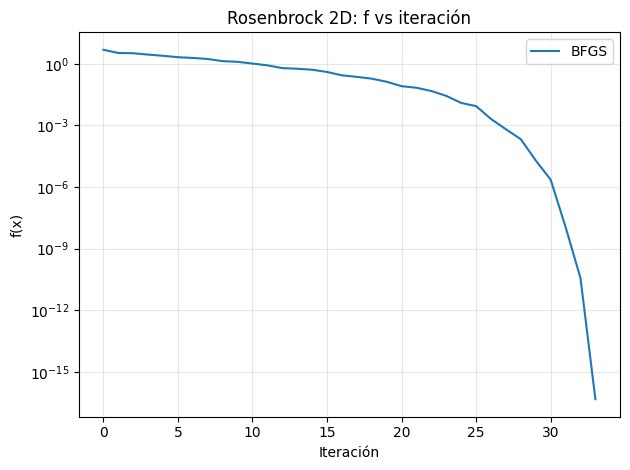

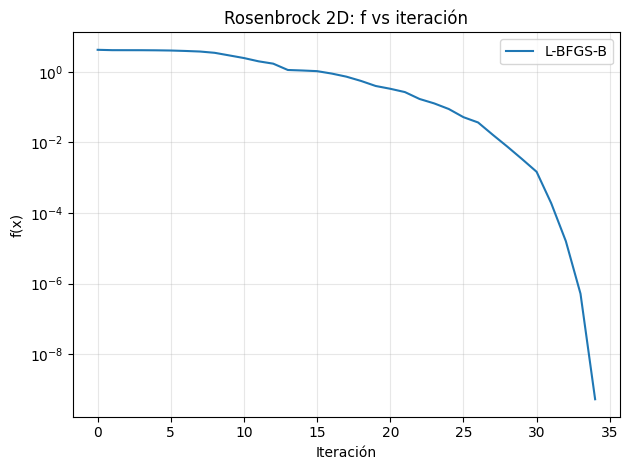

In [10]:
# f vs iteración en Rosenbrock

plt.figure(figsize=(8, 5))
for name, hist in rosen_methods.items():
    if len(hist.f_hist) == 0:
        continue
    plt.plot(hist.f_hist, label=name)
    plt.yscale("log")
    plt.xlabel("Iteración")
    plt.ylabel("f(x)")
    plt.title("Rosenbrock 2D: f vs iteración")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
